# Arbol de decisión aplicado

Tp para la materia de mineria de datos, donde se tomo como base un ejercicio y luego se replico usando otro dataset

## Dataset

Context

Data has been collected from different hospitals, community clinics, maternal health cares through the IoT based risk monitoring system.

    Age: Age in years when a woman is pregnant.
    SystolicBP: Upper value of Blood Pressure in mmHg, another significant attribute during pregnancy.
    DiastolicBP: Lower value of Blood Pressure in mmHg, another significant attribute during pregnancy.
    BS: Blood glucose levels is in terms of a molar concentration, mmol/L.
    HeartRate: A normal resting heart rate in beats per minute.
    Risk Level: Predicted Risk Intensity Level during pregnancy considering the previous attribute.

Estoy usando  el dataset de KAGGLE usando la libreria para descargarlo durante la ejecución https://www.kaggle.com/datasets/csafrit2/maternal-health-risk-data


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("csafrit2/maternal-health-risk-data")

print("Path to dataset files:", path)

100%|██████████| 3.77k/3.77k [00:00<00:00, 6.31MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/csafrit2/maternal-health-risk-data/versions/1


In [2]:
!ls /root/.cache/kagglehub/datasets/csafrit2/maternal-health-risk-data/versions/1

'Maternal Health Risk Data Set.csv'


In [3]:
import pandas as pd
data = pd.read_csv(path+'/Maternal Health Risk Data Set.csv')
data

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


### Examinar datos

Primer vistazo a las columnas y sus datos

In [4]:
# Explorar variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


Salvo la columna RiskLevel, el resto de las columnas son numéricas, que pueden ser de valores enteros como la edad, SystolicBP, DiastolicBP, HeartRate. Las columnas de BS y BodyTemp son del tipo flotante.
La columna de RoskLevel tiene una particularidad que solo puede tener dos valores acotados.

In [5]:
# Rangos de las variables
data.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [6]:
# Verificar distribución categorías
data['RiskLevel'].value_counts()

,count
RiskLevel,
low risk,406
mid risk,336
high risk,272


Existe un desbalance entre 'high risk' y 'low risk'

## Separar elementos de entrada y salida

Separa los elementos entre dependiente(valor a predecir) e independientes(usados para crear la funcion para predecir)

In [7]:
from sklearn.model_selection import train_test_split

# X: entradas, Y: salida a predecir
X = data.iloc[:,:-1]
Y = data.iloc[:,-1]
X

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,25,130,80,15.0,98.0,86
1,35,140,90,13.0,98.0,70
2,29,90,70,8.0,100.0,80
3,30,140,85,7.0,98.0,70
4,35,120,60,6.1,98.0,76
...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80
1010,55,120,90,18.0,98.0,60
1011,35,85,60,19.0,98.0,86
1012,43,120,90,18.0,98.0,70


In [8]:
Y

,RiskLevel
0,high risk
1,high risk
2,high risk
3,high risk
4,low risk
...,...
1009,high risk
1010,high risk
1011,high risk
1012,high risk


## Tansformación de datos

Voy a transformar los valores de RiskLevel para ver si se puede predecir con valor numerico o categorico

In [20]:
# from sklearn.preprocessing import LabelEncoder

class_mapping = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
Y_encoded = Y.map(class_mapping)
Y_encoded


,RiskLevel
0,2
1,2
2,2
3,2
4,0
...,...
1009,2
1010,2
1011,2
1012,2


## Partición de datos
La partición del test será del 0.3

In [21]:
# Partición
x_train, x_test, y_train, y_test = train_test_split(X, Y_encoded, test_size=0.3,
                                                    random_state=123,
                                                    stratify=Y)

# Imprimir tamaños resultantes
print('Tamaño set de entrenamiento (train): ', x_train.shape, y_train.shape)
print('Tamaño set de prueba (test): ', x_test.shape, y_test.shape)

# Distribución de categorías
print('Distribución de categorías dataset original: ', Y.value_counts(normalize=True))
print('Distribución de categorías dataset entrenamiento: ', y_train.value_counts(normalize=True))
print('Distribución de categorías dataset prueba: ', y_test.value_counts(normalize=True))

Tamaño set de entrenamiento (train):  (709, 6) (709,)
Tamaño set de prueba (test):  (305, 6) (305,)
Distribución de categorías dataset original:  RiskLevel
low risk     0.400394
mid risk     0.331361
high risk    0.268245
Name: proportion, dtype: float64
Distribución de categorías dataset entrenamiento:  RiskLevel
0    0.400564
1    0.331453
2    0.267983
Name: proportion, dtype: float64
Distribución de categorías dataset prueba:  RiskLevel
0    0.400000
1    0.331148
2    0.268852
Name: proportion, dtype: float64


## Entrenamiento y visualización de un árbol de clasificación

Creación y entrenamiento del árbol con el set de entrenamiento


In [11]:
from sklearn.tree import DecisionTreeClassifier

# Crear instancia del árbol y entrenar
arbol = DecisionTreeClassifier(random_state=123)
arbol.fit(x_train, y_train)

DecisionTreeClassifier(random_state=123)

In [12]:
# Puntaje set de prueba
score_test = arbol.score(x_test, y_test)
print("F1-score ponderado prueba:", score_test)

F1-score ponderado prueba: 0.8163934426229508


In [13]:
print('Profundidad del árbol: ', arbol.get_depth())
print('Número de hojas del árbol: ', arbol.get_n_leaves())

Profundidad del árbol:  25
Número de hojas del árbol:  153


En general un árbol excesivamente grande (con una profundidad muy alta o con demasiadas hojas) podría tener "overfitting". Generalmente se recomienda reducir la complejidad del árbol, controlando sus hiper-parámetros al momento de crearlo.

## 5. Efecto de los hiper-parámetros en el desempeño del árbol

Comencemos viendo el desempeño del árbol que creamos inicialmente, haciendo uso de la [validación cruzada (*k-fold cross-validation*)](https://codificandobits.com/blog/validacion-cruzada-k-fold-cross-validation/).

Como métrica de desempeño usaremos el F1-ponderado. Comencemos recordando qué son los falsos/verdaderos positivos y los falsos/verdaderos negativos:

- TP (verdaderos positivos): Pacientes con riesgo alto correctamente como 'high risk'
- FP (falsos positivos): sanos detectados incorrectamente como 'high risk'
- TN (verdaderos negativos): sanos detectados correctamente como sanos
- FN (falsos negativos): 'high risk' detectados incorrectamente como sanos

El precision: ¿de todos los clasificados como **high risk** qué porcentaje son realmente **high risk**?:

$$precision = \frac{TP}{TP+FP}$$

El recall: ¿de todos los **high risk** qué proporción fue clasificada realmente como **high risk**?

$$recall = \frac{TP}{TP+FN}$$

Y el F1-score combina el precision y el recall en una sola métrica:

$$F1 = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

Y el F1-score ponderado simplemente modifica ligeramente las ecuaciones anteriores para compensar el desbalance de los datos.

Así que veamos el desempeño (F1-score ponderado) del árbol construido originalmente:

### StratifiedKFold
Divide los datos de forma estratificada, preservando la proporción de clases en cada pliegue.

La estratificación garantiza que la proporción de clases en cada pliegue sea la misma que en el conjunto completo. Esto es importante en problemas de clasificación con datos desbalanceados.

In [14]:
# Validación cruzada
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Crear particiones estratificadas (k=5)
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=123)

- n_splits=5: Divide los datos en 5 pliegues (particiones).
- shuffle=True: Baraja los datos antes de dividirlos.
- random_state=123: Asegura la reproducibilidad del proceso de barajado.


In [15]:
# Realizar validación cruzada (k-fold cross-validation)
arbol = DecisionTreeClassifier(random_state=123)
scores = cross_val_score(arbol, x_train, y_train, cv=skf, scoring='f1_weighted')


- arbol: Instancia del modelo DecisionTreeClassifier.
- x_train, y_train: Datos de entrada y salida de entrenamiento.
- cv=skf: Utiliza las particiones definidas por StratifiedKFold para la validación cruzada.
- scoring='f1_weighted': Utiliza el F1-score ponderado como métrica, que toma en cuenta el desequilibrio de clases.

El resultado es una lista de puntuaciones (una por cada pliegue) que se almacenan en scores.

In [16]:
# Imprimir resultados validación cruzada
print("F1-score ponderado train:", scores.mean())

# Entrenar el árbol con el set de entrenamiento
arbol.fit(x_train,y_train)

# Puntaje set de prueba
score_test = arbol.score(x_test, y_test)
print("F1-score ponderado test:", score_test)

F1-score ponderado train: 0.7866164599149277
F1-score ponderado test: 0.8163934426229508


In [17]:
from sklearn.metrics import f1_score
y_pred = arbol.predict(x_test)
score_test = f1_score(y_test, y_pred, average='weighted')
print("F1-score ponderado prueba:", score_test)

F1-score ponderado prueba: 0.8176836148260422


## Modificando los hiperparametros

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Árbol con "max_depth" = 5

arbol = DecisionTreeClassifier(max_depth=5,
                               random_state=123)
arbol.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=123)

Y veamos si este desempeño cambia al modificar los hiper-parámetros del árbol. Los principales hiper-parámetros son:

- "max_depth": máxima profundidad del árbol (*None* por defecto)
- "min_samples_split": mínimo número de datos para generar partición (2 por defecto)
- "min_samples_leaf": mínimo número de datos que puede contener una hoja (1 por defecto)

Al modificar "max_depth", "min_samples_split" o "min_samples_leaf" haremos que el árbol sea más o menos complejo y esto afectará el desempeño.

Construyamos por ejemplo un árbol con una profundidad máxima de 5:

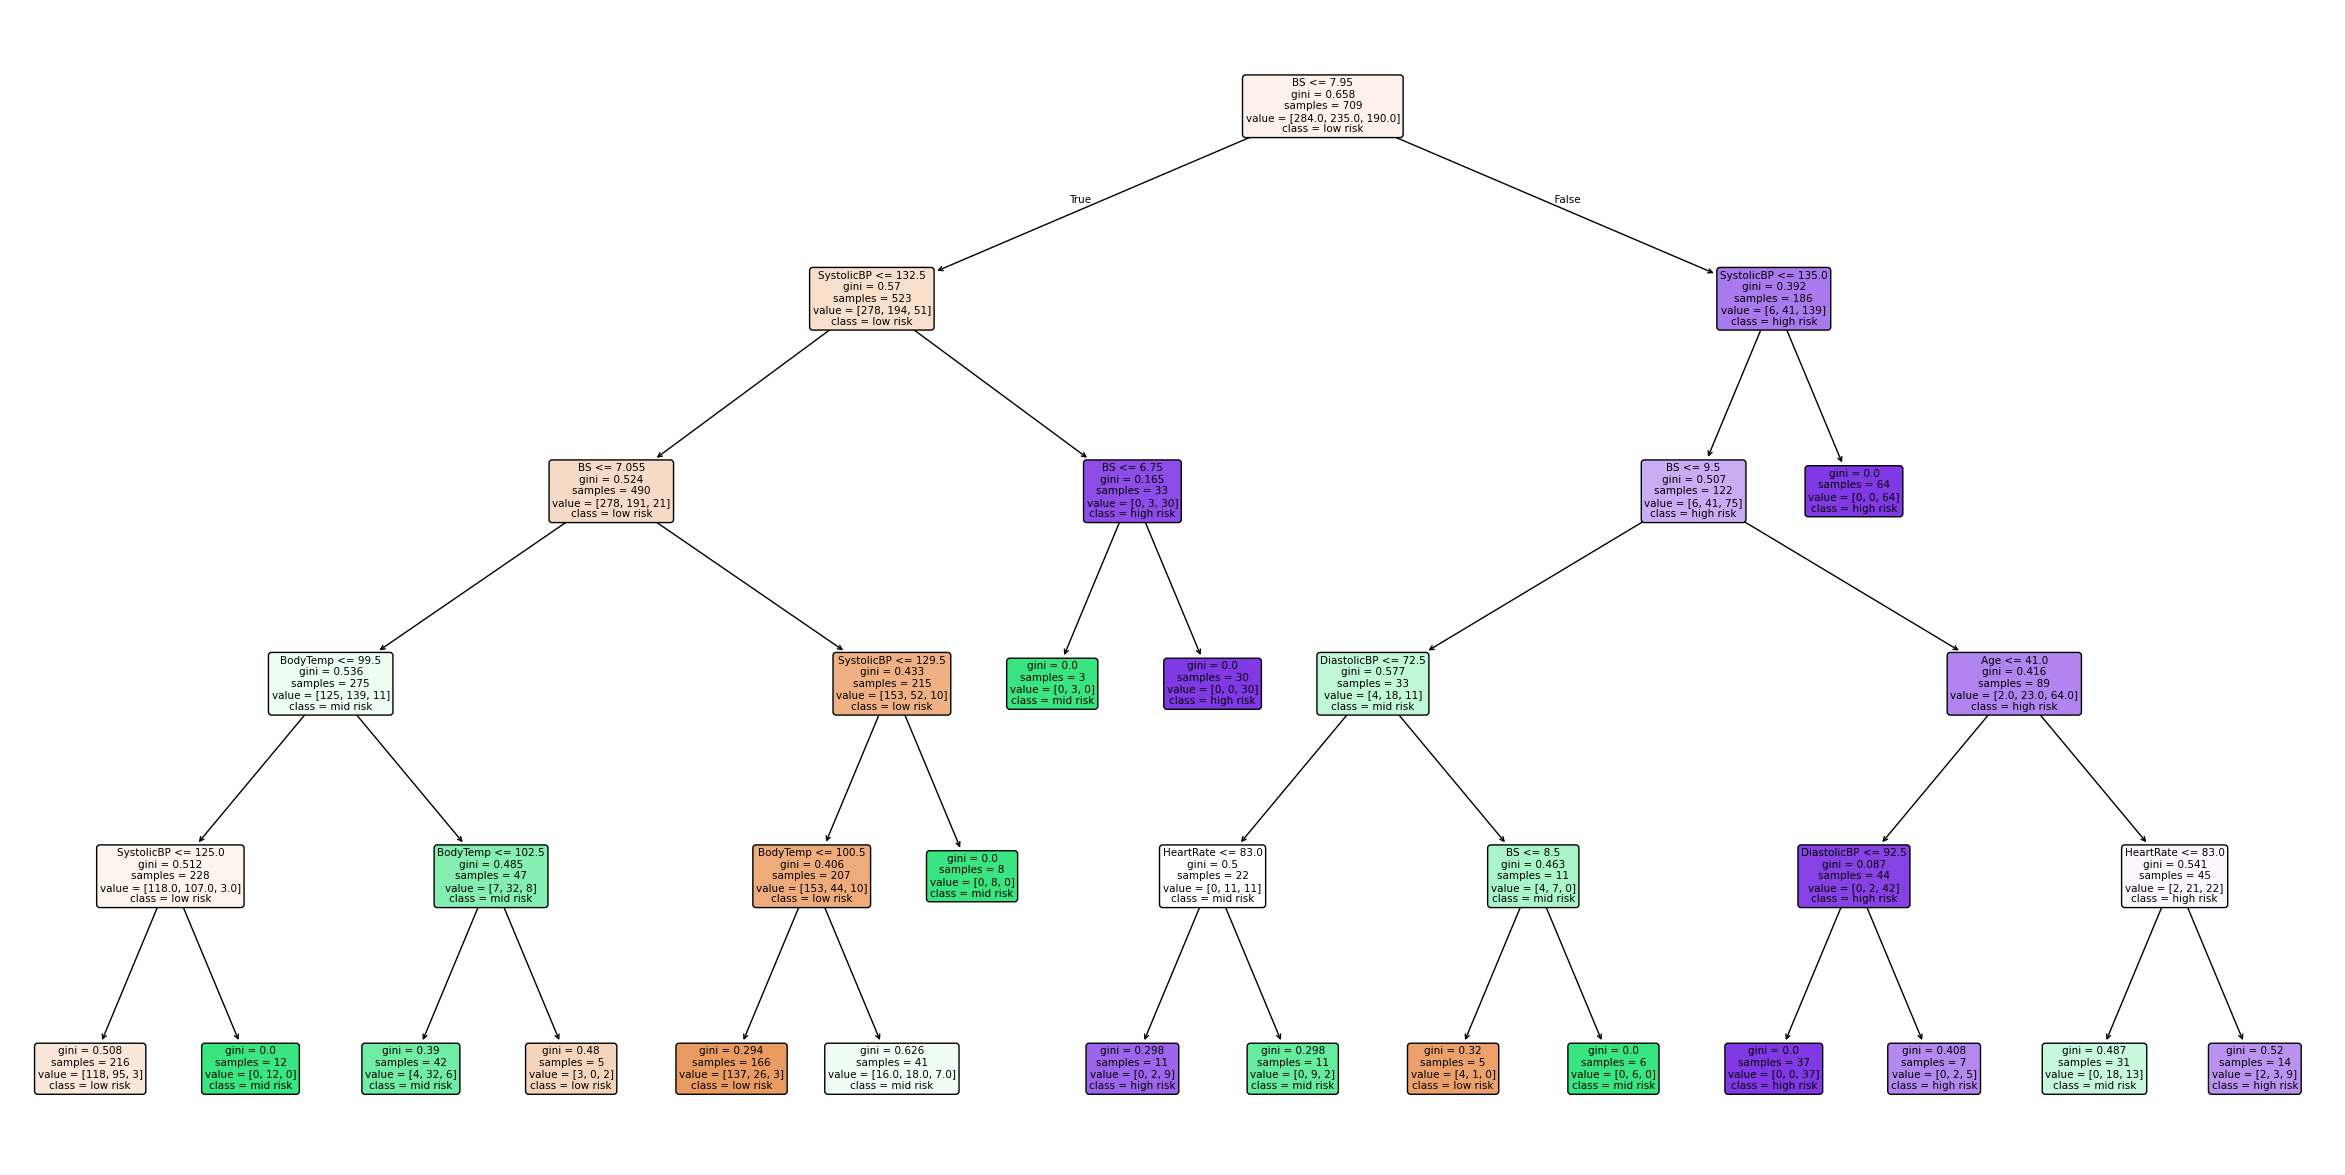

In [19]:

plt.figure(figsize=(30, 15))  # Tamaño de la figura
plot_tree(arbol,
          feature_names=x_train.columns, # Para que contenga los nombres de las características
          class_names = ['low risk', 'mid risk', 'high risk'], # Para que contenga los nombres de las categorías (en orden numérico ascendente)
          filled=True,  # Colorear las hojas con la categoría mayoritaria
          rounded=True, # Bordes redondeados
          )
# Guardar el árbol como archivo PNG de alta resolución
plt.savefig('arbol_clasificacionEntrenamiento_maxdepth_5.png', dpi=700)